In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
df = pd.read_csv("IMDB Dataset.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])
print(df)

                                                  review  sentiment
0      One of the other reviewers has mentioned that ...          1
1      A wonderful little production. <br /><br />The...          1
2      I thought this was a wonderful way to spend ti...          1
3      Basically there's a family where a little boy ...          0
4      Petter Mattei's "Love in the Time of Money" is...          1
...                                                  ...        ...
49995  I thought this movie did a down right good job...          1
49996  Bad plot, bad dialogue, bad acting, idiotic di...          0
49997  I am a Catholic taught in parochial elementary...          0
49998  I'm going to have to disagree with the previou...          0
49999  No one expects the Star Trek movies to be high...          0

[50000 rows x 2 columns]


In [24]:
X = df["review"]
y = df["sentiment"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
cv = CountVectorizer()  # BAG OF WORDS ... JO WORDS KO NO. ME CONVERT KREGA  
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

### Multinomial Naive Bayes is commonly used in NLP because it is designed for discrete features such as word counts or term frequencies. It is fast, memory-efficient, and performs well on text classification tasks like sentiment analysis and spam detection, especially when using Bag of Words or TF-IDF features.

In [ ]:
model = MultinomialNB() # multinomial naive bayes (MultinomialNB) ko hum text classification problems ke liye use karte hain
model.fit(X_train, y_train)

MultinomialNB()

In [28]:
y_pred = model.predict(X_test)

In [29]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8488


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      4961
           1       0.87      0.82      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



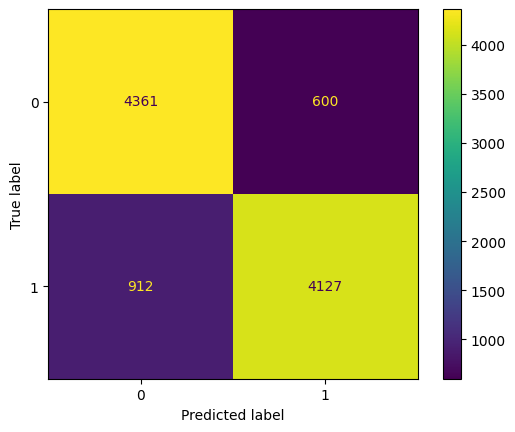

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# model ne kitne samples ko sahi predict kiya aur kitne samples ko galat predict kiya

In [35]:
# TEST ON NEW REVIEW 

review = ["This movie is fantastic"]
review = cv.transform(review)
prediction = model.predict(review)
print(prediction)

# 1 MEANS POSITIVE AND 0 MEANS NEGETIVE 

[1]


In [36]:
review = ["This movie is fantastic BAD"]
review = cv.transform(review)
prediction = model.predict(review)
print(prediction)

[0]
